In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np


from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge


from sklearn.preprocessing import LabelEncoder


0.26123894013987126


'\nparams = {\n    \n}\ngrid_search = GridSearchCV(estimator=reg, param_grid=params,scoring="roc_auc",cv=5,verbose=2,n_jobs=-1)\ngrid_search.fit(X_train,y_train)\n\nbestest = grid_search.best_estimator_\npreds = bestest.predict_proba(X_test)\nprint(grid_search.best_params_)\nbestest.fit(X_train, y_train)\nprint("AUC: " + str(roc_auc_score(y_test, preds[:,1])))\nfeat_importances = pd.Series(bestest.feature_importances_, index=X.columns)\nfeat_importances.nlargest(20).plot(kind=\'barh\')\nplt.title("Random Forest Feature Importance")\n'

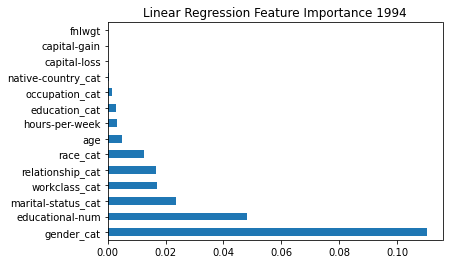

In [ ]:
X = pd.read_csv("X_1994.csv")
X.drop(columns=X.columns[0], 
        axis=1, 
        inplace=True)
X = pd.get_dummies(data=X,drop_first=True)
y = pd.read_csv("y_1994.csv")
y.drop(columns=y.columns[0], 
        axis=1, 
        inplace=True)
y = pd.get_dummies(data=y,drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
reg = LinearRegression()
model = reg.fit(X_train,y_train)
score = model.score(X_test,y_test)
print(score)
feat_importances = pd.Series(abs(model.coef_[0]),index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Linear Regression Feature Importance 1994")

"""
params = {
    
}
grid_search = GridSearchCV(estimator=reg, param_grid=params,scoring="roc_auc",cv=5,verbose=2,n_jobs=-1)
grid_search.fit(X_train,y_train)

bestest = grid_search.best_estimator_
preds = bestest.predict_proba(X_test)
print(grid_search.best_params_)
bestest.fit(X_train, y_train)
print("AUC: " + str(roc_auc_score(y_test, preds[:,1])))
feat_importances = pd.Series(bestest.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.title("Random Forest Feature Importance")
"""

In [ ]:
score = np.mean(auc_cv(model,X,y))
print(score)

0.8207999385360203


In [ ]:
from sklearn.model_selection import cross_val_score
def auc_cv(model,my_X,my_y):
    score = cross_val_score(model, my_X, my_y, scoring="roc_auc", cv = 5)
    return(score)

0        False
1        False
2        False
3        False
4        False
         ...  
38571     True
38572     True
38573    False
38574     True
38575    False
Name: income-90k-threshold, Length: 38576, dtype: bool